# **Predict Credit Consumption of Customer For Leading Bank**


## Business Problem: 
* Some customers are having missing values for credit consumption. 
* You need to build the model using customer’s data where credit consumption is non- missing’s. 
* You need to predict the credit consumption for next three months for the customers having missing values.

## Model Evaluation Metric:
#### You should validate model using Root Mean Square Percentage Error (RMSPE) between the predicted credit card consumption and Actual Credit Consumption.


In [1]:
# Load the Datasets

import pandas as pd 
import numpy as np

demo   =  pd.read_excel("CustomerDemographics.xlsx")
behav  =  pd.read_excel("CustomerBehaviorData.xlsx")
target =  pd.read_excel("CreditConsumptionData.xlsx")


In [2]:
demo.head()

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction
0,17051,current,M,30,MEDIUM,26.4,9,9,355,0
1,11491,current,M,37,LOW,14.4,7,7,485,0
2,7433,current,M,33,MEDIUM,3.2,1,1,764,0
3,14606,current,M,63,LOW,10.2,6,6,863,0
4,8381,saving,M,33,MEDIUM,26.4,6,6,523,0


In [3]:
behav.head()

,ID,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,cc_count_jun,...,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,loan_enq,emi_active
0,17051,2017.46,29066.66,15919.84,2197.00,3752.000,29798.00,1.0,4,35,...,47,20,41860.0,32734.75,80959.00,36,9,171200.0,Y,3448.84
1,11491,7687.00,1308.00,41888.92,2216.92,7060.530,3143.36,2.0,27,50,...,0,8,113367.0,60974.75,495080.00,5,3,15694.0,Y,3812.69
2,7433,9094.46,14825.95,3087.64,769.59,25602.595,1445.00,44.0,8,47,...,2,14,168000.0,425802.96,115707.38,7,58,28058.0,Y,9432.90
3,14606,3126.00,4616.33,8676.80,5923.00,6717.000,18747.00,4.0,30,1,...,45,44,57750.0,25537.91,63606.00,12,0,24459.0,Y,144.61
4,8381,24988.72,10091.23,10132.00,3477.00,4667.000,511.00,2.0,8,5,...,1,2,18405.0,64687.32,62353.35,49,35,31574.0,Y,1887.89


In [4]:
target.head()

,ID,cc_cons
0,17051,16239.0
1,11491,39002.0
2,7433,21182.0
3,14606,8123.0
4,8381,28282.0


In [5]:
# Merge the Datasets

df = demo.merge(behav, on = "ID")
df = df.merge(target, on = "ID")
df.head()

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,...,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,loan_enq,emi_active,cc_cons
0,17051,current,M,30,MEDIUM,26.4,9,9,355,0,...,20,41860.0,32734.75,80959.00,36,9,171200.0,Y,3448.84,16239.0
1,11491,current,M,37,LOW,14.4,7,7,485,0,...,8,113367.0,60974.75,495080.00,5,3,15694.0,Y,3812.69,39002.0
2,7433,current,M,33,MEDIUM,3.2,1,1,764,0,...,14,168000.0,425802.96,115707.38,7,58,28058.0,Y,9432.90,21182.0
3,14606,current,M,63,LOW,10.2,6,6,863,0,...,44,57750.0,25537.91,63606.00,12,0,24459.0,Y,144.61,8123.0
4,8381,saving,M,33,MEDIUM,26.4,6,6,523,0,...,2,18405.0,64687.32,62353.35,49,35,31574.0,Y,1887.89,28282.0


In [6]:
# Missing Value Analysis

df.isnull().sum()

ID                                 0
account_type                       0
gender                             0
age                                0
Income                             0
Emp_Tenure_Years                   0
Tenure_with_Bank                   0
region_code                        0
NetBanking_Flag                    0
Avg_days_between_transaction       0
cc_cons_apr                        0
dc_cons_apr                        0
cc_cons_may                        1
dc_cons_may                        1
cc_cons_jun                        0
dc_cons_jun                        1
cc_count_apr                       1
cc_count_may                       0
cc_count_jun                       0
dc_count_apr                       0
dc_count_may                       0
dc_count_jun                       0
card_lim                           0
personal_loan_active               0
vehicle_loan_active                0
personal_loan_closed               1
vehicle_loan_closed                0
i

In [7]:
# Resolve the Null-Values

df["cc_cons_may"] = df["cc_cons_may"].fillna(df["cc_cons_may"].median())
df["dc_cons_may"] = df["dc_cons_may"].fillna(df["dc_cons_may"].median())

df["cc_count_apr"] = df["cc_count_apr"].fillna(df["cc_count_apr"].median())
df["dc_cons_jun"] = df["dc_cons_jun"].fillna(df["dc_cons_jun"].median())

df["personal_loan_closed"] = df["personal_loan_closed"].fillna(df["personal_loan_closed"].median())

df["investment_3"] = df["investment_3"].fillna(df["investment_3"].median())

df["debit_count_apr"] = df["debit_count_apr"].fillna(df["debit_count_apr"].median())

df["loan_enq"] = df["loan_enq"].fillna('Y')

df["emi_active"] = df["emi_active"].fillna(df["emi_active"].median())


In [8]:
df.loan_enq.unique()

array(['Y'], dtype=object)

In [9]:
df.isnull().sum()

ID                                 0
account_type                       0
gender                             0
age                                0
Income                             0
Emp_Tenure_Years                   0
Tenure_with_Bank                   0
region_code                        0
NetBanking_Flag                    0
Avg_days_between_transaction       0
cc_cons_apr                        0
dc_cons_apr                        0
cc_cons_may                        0
dc_cons_may                        0
cc_cons_jun                        0
dc_cons_jun                        0
cc_count_apr                       0
cc_count_may                       0
cc_count_jun                       0
dc_count_apr                       0
dc_count_may                       0
dc_count_jun                       0
card_lim                           0
personal_loan_active               0
vehicle_loan_active                0
personal_loan_closed               0
vehicle_loan_closed                0
i

In [10]:
df["cc_cons"].isnull().sum()

np.int64(5000)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   account_type                  20000 non-null  object 
 2   gender                        20000 non-null  object 
 3   age                           20000 non-null  int64  
 4   Income                        20000 non-null  object 
 5   Emp_Tenure_Years              20000 non-null  float64
 6   Tenure_with_Bank              20000 non-null  int64  
 7   region_code                   20000 non-null  int64  
 8   NetBanking_Flag               20000 non-null  int64  
 9   Avg_days_between_transaction  20000 non-null  int64  
 10  cc_cons_apr                   20000 non-null  float64
 11  dc_cons_apr                   20000 non-null  float64
 12  cc_cons_may                   20000 non-null  float64
 13  d

In [11]:
cat_cols = ['account_type','gender','Income','loan_enq']

# by loop

In [12]:
df.account_type.unique()

array(['current', 'saving', 0], dtype=object)

In [13]:
df.gender.unique()

array(['M', 'F', 0], dtype=object)

In [14]:
df.Income.unique()

array(['MEDIUM', 'LOW', 'HIGH', 0], dtype=object)

In [15]:
df.loan_enq.unique()

array(['Y'], dtype=object)

In [16]:
# Data Preprocessing

df = pd.get_dummies(df, columns = cat_cols, dtype = int)    # converting the categorical columns into numerical columns by OneHotEncoder

In [17]:
df.dtypes       # Now all are non-categorical columns

ID                                int64
age                               int64
Emp_Tenure_Years                float64
Tenure_with_Bank                  int64
region_code                       int64
NetBanking_Flag                   int64
Avg_days_between_transaction      int64
cc_cons_apr                     float64
dc_cons_apr                     float64
cc_cons_may                     float64
dc_cons_may                     float64
cc_cons_jun                     float64
dc_cons_jun                     float64
cc_count_apr                    float64
cc_count_may                      int64
cc_count_jun                      int64
dc_count_apr                      int64
dc_count_may                      int64
dc_count_jun                      int64
card_lim                          int64
personal_loan_active              int64
vehicle_loan_active               int64
personal_loan_closed            float64
vehicle_loan_closed               int64
investment_1                    float64


In [18]:
df.head()

,ID,age,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,cc_cons_apr,dc_cons_apr,cc_cons_may,...,account_type_current,account_type_saving,gender_0,gender_F,gender_M,Income_0,Income_HIGH,Income_LOW,Income_MEDIUM,loan_enq_Y
0,17051,30,26.4,9,9,355,0,2017.46,29066.66,15919.84,...,1,0,0,0,1,0,0,0,1,1
1,11491,37,14.4,7,7,485,0,7687.00,1308.00,41888.92,...,1,0,0,0,1,0,0,1,0,1
2,7433,33,3.2,1,1,764,0,9094.46,14825.95,3087.64,...,1,0,0,0,1,0,0,0,1,1
3,14606,63,10.2,6,6,863,0,3126.00,4616.33,8676.80,...,1,0,0,0,1,0,0,1,0,1
4,8381,33,26.4,6,6,523,0,24988.72,10091.23,10132.00,...,0,1,0,0,1,0,0,0,1,1


In [19]:
# Create train_df and pred_df

In [20]:
train_df = df[df["cc_cons"].notnull()]
train_df.head()                            # cc_cons is not null that is present in last column on this we will train the model

,ID,age,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,cc_cons_apr,dc_cons_apr,cc_cons_may,...,account_type_current,account_type_saving,gender_0,gender_F,gender_M,Income_0,Income_HIGH,Income_LOW,Income_MEDIUM,loan_enq_Y
0,17051,30,26.4,9,9,355,0,2017.46,29066.66,15919.84,...,1,0,0,0,1,0,0,0,1,1
1,11491,37,14.4,7,7,485,0,7687.00,1308.00,41888.92,...,1,0,0,0,1,0,0,1,0,1
2,7433,33,3.2,1,1,764,0,9094.46,14825.95,3087.64,...,1,0,0,0,1,0,0,0,1,1
3,14606,63,10.2,6,6,863,0,3126.00,4616.33,8676.80,...,1,0,0,0,1,0,0,1,0,1
4,8381,33,26.4,6,6,523,0,24988.72,10091.23,10132.00,...,0,1,0,0,1,0,0,0,1,1


In [21]:
pred_df = df[df['cc_cons'].isnull()]
pred_df.head()                            # cc_cons is null that is present in last column which we have to predict for cc_cons.

,ID,age,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,cc_cons_apr,dc_cons_apr,cc_cons_may,...,account_type_current,account_type_saving,gender_0,gender_F,gender_M,Income_0,Income_HIGH,Income_LOW,Income_MEDIUM,loan_enq_Y
15000,17591,37,11.9,4,4,575,1,2795.45,1290.0,6141.05,...,1,0,0,0,1,0,0,0,1,1
15001,13541,33,7.8,6,6,394,0,29405.13,1640.0,1670.00,...,1,0,0,0,1,0,0,0,1,1
15002,13431,53,33.0,10,10,324,1,5985.20,6189.0,2696.09,...,1,0,0,0,1,0,0,1,0,1
15003,8687,33,7.8,5,5,370,1,2105.93,18225.0,34763.56,...,1,0,0,0,1,0,0,0,1,1
15004,14727,62,12.6,9,9,505,1,3269.00,3532.0,3158.40,...,1,0,0,0,1,0,0,1,0,1


In [22]:
train_df.isnull().sum()

ID                              0
age                             0
Emp_Tenure_Years                0
Tenure_with_Bank                0
region_code                     0
NetBanking_Flag                 0
Avg_days_between_transaction    0
cc_cons_apr                     0
dc_cons_apr                     0
cc_cons_may                     0
dc_cons_may                     0
cc_cons_jun                     0
dc_cons_jun                     0
cc_count_apr                    0
cc_count_may                    0
cc_count_jun                    0
dc_count_apr                    0
dc_count_may                    0
dc_count_jun                    0
card_lim                        0
personal_loan_active            0
vehicle_loan_active             0
personal_loan_closed            0
vehicle_loan_closed             0
investment_1                    0
investment_2                    0
investment_3                    0
investment_4                    0
debit_amount_apr                0
credit_amount_

In [23]:
pred_df.isnull().sum()

ID                                 0
age                                0
Emp_Tenure_Years                   0
Tenure_with_Bank                   0
region_code                        0
NetBanking_Flag                    0
Avg_days_between_transaction       0
cc_cons_apr                        0
dc_cons_apr                        0
cc_cons_may                        0
dc_cons_may                        0
cc_cons_jun                        0
dc_cons_jun                        0
cc_count_apr                       0
cc_count_may                       0
cc_count_jun                       0
dc_count_apr                       0
dc_count_may                       0
dc_count_jun                       0
card_lim                           0
personal_loan_active               0
vehicle_loan_active                0
personal_loan_closed               0
vehicle_loan_closed                0
investment_1                       0
investment_2                       0
investment_3                       0
i

In [24]:
# Feature Selection

X = train_df.drop(columns = ["ID","cc_cons"], axis = 1)
y = train_df["cc_cons"]

In [25]:
# Separating the prediction data from the pred_df for further prediction

X_pred = pred_df.drop(columns = ["ID","cc_cons"], axis = 1)   # Prediction dataset

In [26]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [27]:
# Linear Regression

from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred_lr = model_lr.predict(X_test)
y_pred_lr

array([ 4120.91617334,  6533.21220539, 12029.26156208, ...,
        4691.88097494,  6534.28307706,  3000.62786235])

In [29]:
# Metrics Evaluation for LinearRegression :

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, accuracy_score

rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
print("RMSE_lr : ", rmse_lr)
                                                                # Both methods calculate the same value
RMSE = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("RMSE_lr : ",RMSE)

rmspe_lr = np.sqrt(np.mean(np.square((y_test - y_pred_lr)/y_test)))
print("rmspe_lr : ",rmspe_lr)

r2_score_lr = r2_score(y_test, y_pred_lr)
print("r2_score_lr : ",r2_score_lr)

# accuracy_score = accuracy_score(y_test, y_pred)
# print("accuracy_score : ",accuracy_score)

RMSE_lr :  2609.2072085572136
RMSE_lr :  2609.2072085572136
rmspe_lr :  0.26892709268354925
r2_score_lr :  0.8644545273459967


In [30]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators = 300, random_state = 42)
model_rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [31]:
y_pred_rf = model_rf.predict(X_test)
y_pred_rf

array([ 3581.109742  ,  5988.831741  , 11306.44997033, ...,
        4335.04442933,  6545.557657  ,  2743.85307033])

In [32]:
# Metrics Evaluation for RandomForestRegressor :

from sklearn.metrics import root_mean_squared_error, r2_score
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
print("RMSE_rf : ", rmse_rf)

rmse_rf = np.sqrt(np.mean(np.square(y_test - y_pred_rf)))
print("RMSE_rf : ",rmse_rf)
                                                                           # Both methods calculate the same value
rmspe_rf = np.sqrt(np.mean(np.square((y_test - y_pred_rf) / y_test)))
print("RMSPE_rf : ", rmspe_rf)

r2_score_rf = r2_score(y_test, y_pred_rf)
print("r2_score_rf : ", r2_score_rf)



RMSE_rf :  2854.6342255391924
RMSE_rf :  2854.6342255391924
RMSPE_rf :  0.28705285401164515
r2_score_rf :  0.8377559369242683


In [33]:
#  Feature Importance

importances = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : model_rf.feature_importances_
})

importance = importances.sort_values(by = "Importance", ascending = False)
importance.head(20)

,Feature,Importance
8,cc_cons_may,0.289536
6,cc_cons_apr,0.251784
9,dc_cons_may,0.138107
10,cc_cons_jun,0.129031
7,dc_cons_apr,0.080795
42,emi_active,0.004646
38,credit_amount_jun,0.004280
41,max_credit_amount_jun,0.004188
11,dc_cons_jun,0.004156
32,debit_amount_may,0.004047


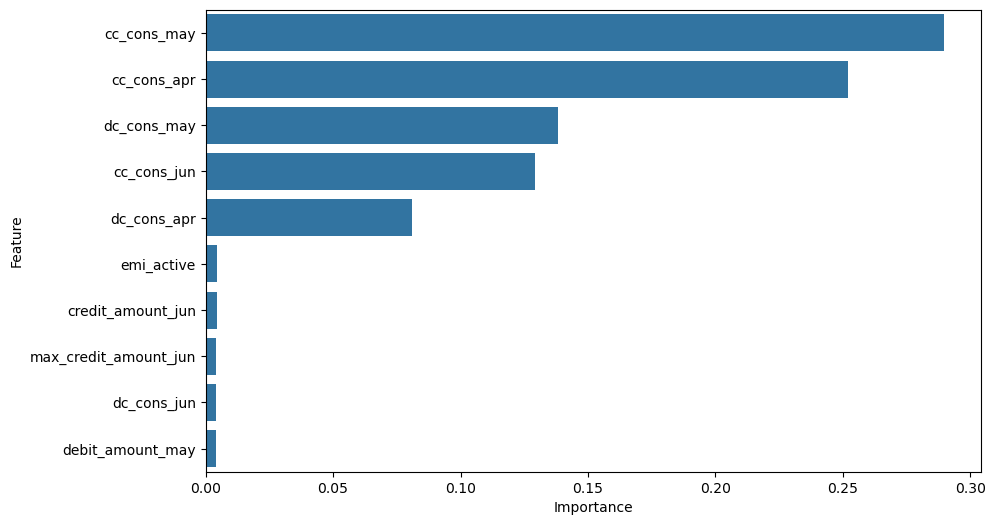

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.show()

In [35]:
# Predict Missing Customers

final_pred = model_rf.predict(X_pred)
final_pred

array([2843.928923  , 7491.00494267, 2937.11490567, ..., 4215.30056567,
       6808.012289  , 6464.80793733])

In [36]:
result = pd.DataFrame({
    "ID" : pred_df["ID"],
    "CC_Consumption" : final_pred
})
result
    

,ID,CC_Consumption
15000,17591,2843.928923
15001,13541,7491.004943
15002,13431,2937.114906
15003,8687,8723.024654
15004,14727,2189.446177
...,...,...
19995,12512,9650.940017
19996,14224,6095.023949
19997,18740,4215.300566
19998,18134,6808.012289


In [37]:
# Export CSV

result.to_csv("Predicted_CC_Consumption.csv", index=False)

In [38]:
comparison = pd.DataFrame({

'Model':['Linear Regression','Random Forest'],
'RMSE':[rmse_lr,rmse_rf],
'R2 Score':[r2_score_lr,r2_score_rf],
'RMSPE':[rmspe_lr, rmspe_rf]
})

comparison

,Model,RMSE,R2 Score,RMSPE
0,Linear Regression,2609.207209,0.864455,0.268927
1,Random Forest,2854.634226,0.837756,0.287053


## Project Conclusion
### Best Model : Linear Regression 

* Linear Regression performed better than Random Forest.
* It achieved a lower RMSE of 2609.21 compared to 2854.63, a higher R² Score of 86.45% compared to 83.78%,
* and a lower RMSPE of 26.89% compared to 28.71%. Therefore, Linear Regression was selected as the final model.